# General Equilibrium & Mission Drift under Pareto Returns
**Social Finance -- Online Appendix and Notebook 6**

This notebook implements the general equilibrium model of a social and commercial banking market clearing when **project returns $X_s$ follow a Pareto distribution**:
$$X_s \sim \text{Pareto}[X_m,\; \alpha_{\text{pareto}}]$$

Unlike the Uniform distribution in `5-endogenous-NK.ipynb`, the Pareto distribution is highly right-skewed with most project returns concentrated near the minimum value $X_m$ and a long, thin tail of highly productive projects. This creates a very different spatial capital allocation profile, where commercial MFIs strongly concentrate their scarce capital in wealthier areas.

In [1]:
import sys
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')  # non-interactive backend for batch execution
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import root_scalar, brentq
from scipy.integrate import quad

# Path configuration to find local packages
sys.path.append(os.path.abspath('..'))

# Matplotlib styling
plt.rcParams['figure.figsize'] = (8.5, 6.0)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.6
plt.rcParams['font.size'] = 11

# Import the core Bank class
from socialfinance.socialfinance import Bank, BankHetX

os.makedirs('figs', exist_ok=True)
print('Imports complete.')

Imports complete.


## 1. Analytical Foundations

### The Pareto Model

We assume that within each neighborhood $j$ (characterized by pledgeable assets $A_j$), there is a finite population $\bar{N}$ of potential borrowers. Each borrower has a project with success return $X_s$ drawn i.i.d. from a common Pareto distribution:

$$g(x) = \frac{\alpha_{\text{pareto}} X_m^{\alpha_{\text{pareto}}}}{x^{\alpha_{\text{pareto}} + 1}}, \quad \text{for } x \geq X_m$$

The cumulative distribution function is:
$$G(x) = 1 - \left(\frac{X_m}{x}\right)^{\alpha_{\text{pareto}}}$$

### Modified Contract Equations

The minimum collateral requirement under leveraged intermediation remains:
$$\underline{A}(m, X_s) = \frac{p(B_0 - \alpha m)}{\Delta} - [p X_s - \gamma I] + m + \frac{\beta - \gamma}{\beta} \frac{q m}{\Delta} + \beta f$$

The MFI serves borrowers with $X_s \geq X_s^*(A_j, \beta)$, where $X_s^* = \max\{X_s^{(a)}, X_s^{(b)}\}$.

### Outreach & Capital Demand under Pareto
Because $X_s$ follows a Pareto distribution, the fraction of the population served in neighborhood $A_j$ is:

$$\text{frac\_served}(A_j) = 1 - G(X_s^*) = \left(\frac{X_m}{X_s^*(A_j)}\right)^{\alpha_{\text{pareto}}}$$

The aggregate MFI capital demand in neighborhood $j$ is computed by integrating the required skin-in-the-game equity $I^m(m^*(x))$ over the Pareto density from $X_s^*$ to $X_{nm}$:

$$K_j(A_j) = N_{\text{pop}} \int_{X_s^*}^{X_{nm}} \frac{q m^*(x)}{\beta \Delta} \cdot g(x) \, dx$$

We have derived the closed-form analytical integral for this demand:
$$K_j = K_0 \left[ -\frac{A_0}{\alpha_{\text{pareto}}} x^{-\alpha_{\text{pareto}}} + \frac{p}{\alpha_{\text{pareto}} - 1} x^{-(\alpha_{\text{pareto}} - 1)} \right]_{X_{star}}^{X_{nm}}$$
where $K_0 = N_{\text{pop}} \cdot \frac{q}{D} \cdot \alpha_{\text{pareto}} X_m^{\alpha_{\text{pareto}}}$ and $A_0 = \frac{p B_0}{\Delta} + \gamma I + \beta f - A_j$.

## 2. Validation: Recovering the Baseline

Before exploring the new model, let's verify that `BankHetX` recovers the baseline when $X_s$ degenerates to a point mass at $X = 200$. We also verify the analytical $X_s^*$ formula against numerical root-finding.

In [2]:
import numpy as np
from socialfinance.socialfinance import BankHetX

A_test = np.array([30.0, 60.0, 90.0, 120.0])
beta_test = 1.2

# BankHetX under Pareto with X_m = 160, alpha_pareto = 3.0
bank_het = BankHetX(A_test, beta=beta_test, dist_type='pareto', X_m=160, alpha_pareto=3.0)

print("=== Validation: Pareto Cutoffs ===")
for a in A_test:
    xs_star = bank_het.X_star(a)
    xs_nm = bank_het.X_no_monitoring(a)
    frac = bank_het.frac_served(a)
    print(f"A_j = {a:.1f}: X_star = {xs_star:.2f}, X_nm = {xs_nm:.2f}, Fraction served = {frac:.4f}")


=== Validation: Pareto Cutoffs ===
A_j = 30.0: X_star = 223.64, X_nm = 292.78, Fraction served = 0.3662
A_j = 60.0: X_star = 205.36, X_nm = 261.86, Fraction served = 0.4729
A_j = 90.0: X_star = 187.08, X_nm = 230.93, Fraction served = 0.6255
A_j = 120.0: X_star = 168.80, X_nm = 200.00, Fraction served = 0.8516


## 3. The Credit Demand Curve Within a Neighborhood

For a single neighborhood $A_j$, we can now visualize the **intensive margin**: how the MFI's lending expands as it dips deeper into the $X_s$ distribution. 

For each served borrower, we plot:
- Required monitoring $m^*(A_j, X_s)$ — declining in $X_s$
- Borrower surplus $\pi(A_j, X_s)$ — increasing in $X_s$  
- MFI equity stake $I^m(A_j, X_s)$ — declining in $X_s$

The **marginal borrower** at the cutoff $X_s^*$ earns zero surplus and absorbs the most monitoring.

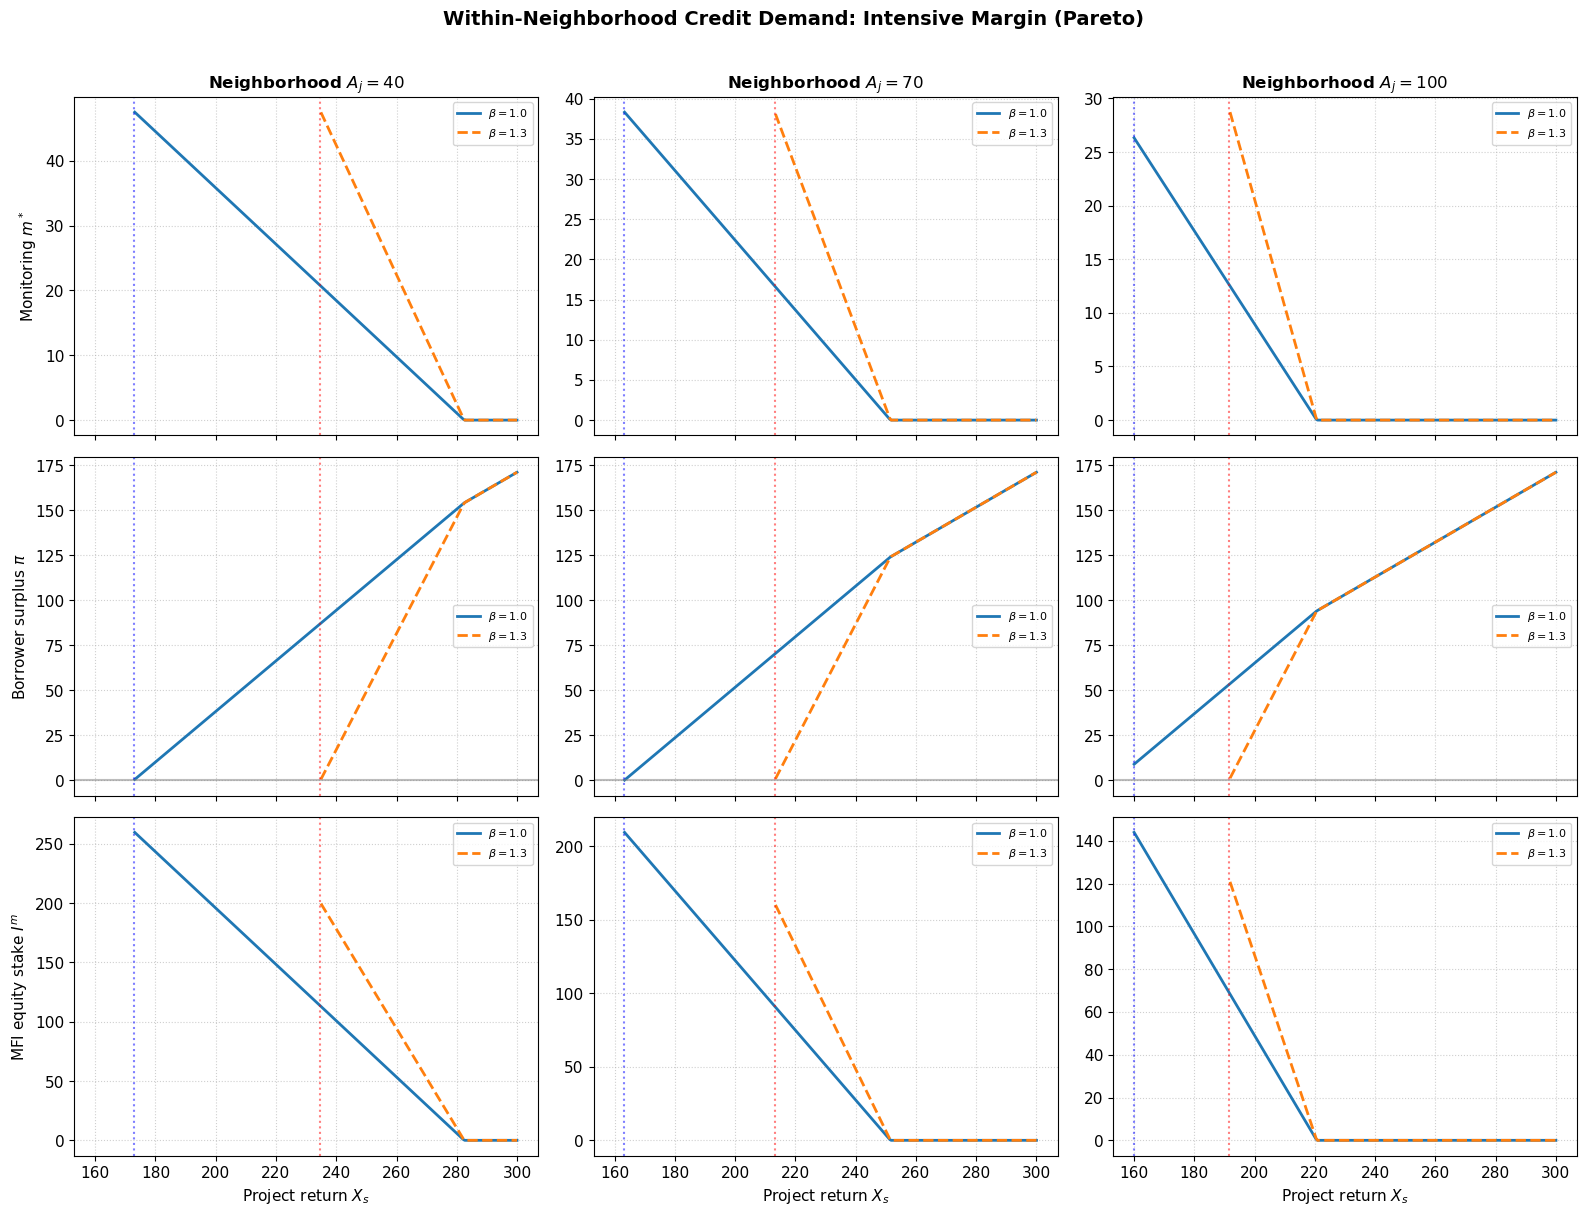

In [3]:
# Credit demand curves for selected neighborhoods

beta_vals_to_show = [1.0, 1.3]
A_neighborhoods = [40, 70, 100]
X_grid = np.linspace(160, 300, 300)

fig, axes = plt.subplots(3, len(A_neighborhoods), figsize=(16, 12), sharex=True)

for col, A_j in enumerate(A_neighborhoods):
    for beta_v, ls, lbl_sfx in zip(beta_vals_to_show, ['-', '--'], 
                                     [r'$\beta=1.0$', r'$\beta=1.3$']):
        bank = BankHetX(np.array([A_j]), beta=beta_v, dist_type='pareto', X_m=160, alpha_pareto=3.0)
        xs = bank.X_star(A_j)
        
        m_vals = np.array([bank.m_opt_Xs(A_j, x) for x in X_grid])
        surplus_vals = np.array([bank.borrower_surplus_Xs(A_j, x) for x in X_grid])
        Im_vals = np.array([bank.Im_Xs(bank.m_opt_Xs(A_j, x)) for x in X_grid])
        
        # Zero out below X_star
        mask = X_grid >= xs
        
        axes[0, col].plot(X_grid[mask], m_vals[mask], ls, linewidth=2, label=lbl_sfx)
        axes[0, col].axvline(x=xs, color='red' if beta_v > 1.1 else 'blue', 
                             linestyle=':', alpha=0.5)
        
        axes[1, col].plot(X_grid[mask], surplus_vals[mask], ls, linewidth=2, label=lbl_sfx)
        axes[1, col].axhline(y=0, color='grey', linestyle='-', alpha=0.3)
        axes[1, col].axvline(x=xs, color='red' if beta_v > 1.1 else 'blue', 
                             linestyle=':', alpha=0.5)
        
        axes[2, col].plot(X_grid[mask], Im_vals[mask], ls, linewidth=2, label=lbl_sfx)
        axes[2, col].axvline(x=xs, color='red' if beta_v > 1.1 else 'blue', 
                             linestyle=':', alpha=0.5)
    
    axes[0, col].set_title(f'Neighborhood $A_j = {A_j}$', fontsize=12, weight='bold')

axes[0, 0].set_ylabel('Monitoring $m^*$')
axes[1, 0].set_ylabel('Borrower surplus $\\pi$')
axes[2, 0].set_ylabel('MFI equity stake $I^m$')

for ax in axes[2, :]:
    ax.set_xlabel('Project return $X_s$')

for ax in axes.flat:
    ax.legend(fontsize=8)

fig.suptitle('Within-Neighborhood Credit Demand: Intensive Margin (Pareto)', 
             fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figs/fig-within-nbhd-demand-pareto.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. The Outreach Landscape with Heterogeneous Projects

Now we can compute the **outreach landscape** across neighborhoods. For each neighborhood $A_j$, we compute:

1. **Fraction served** $[1 - G(X_s^*(A_j, \beta))]$ — what share of the local population gets credit
2. **Total equity demanded** $K_j(\beta)$ — how much monitoring capital is absorbed
3. **Total borrower surplus** — welfare generated

We compare the social benchmark ($\beta = \gamma = 1.0$) with a range of commercial hurdle rates.

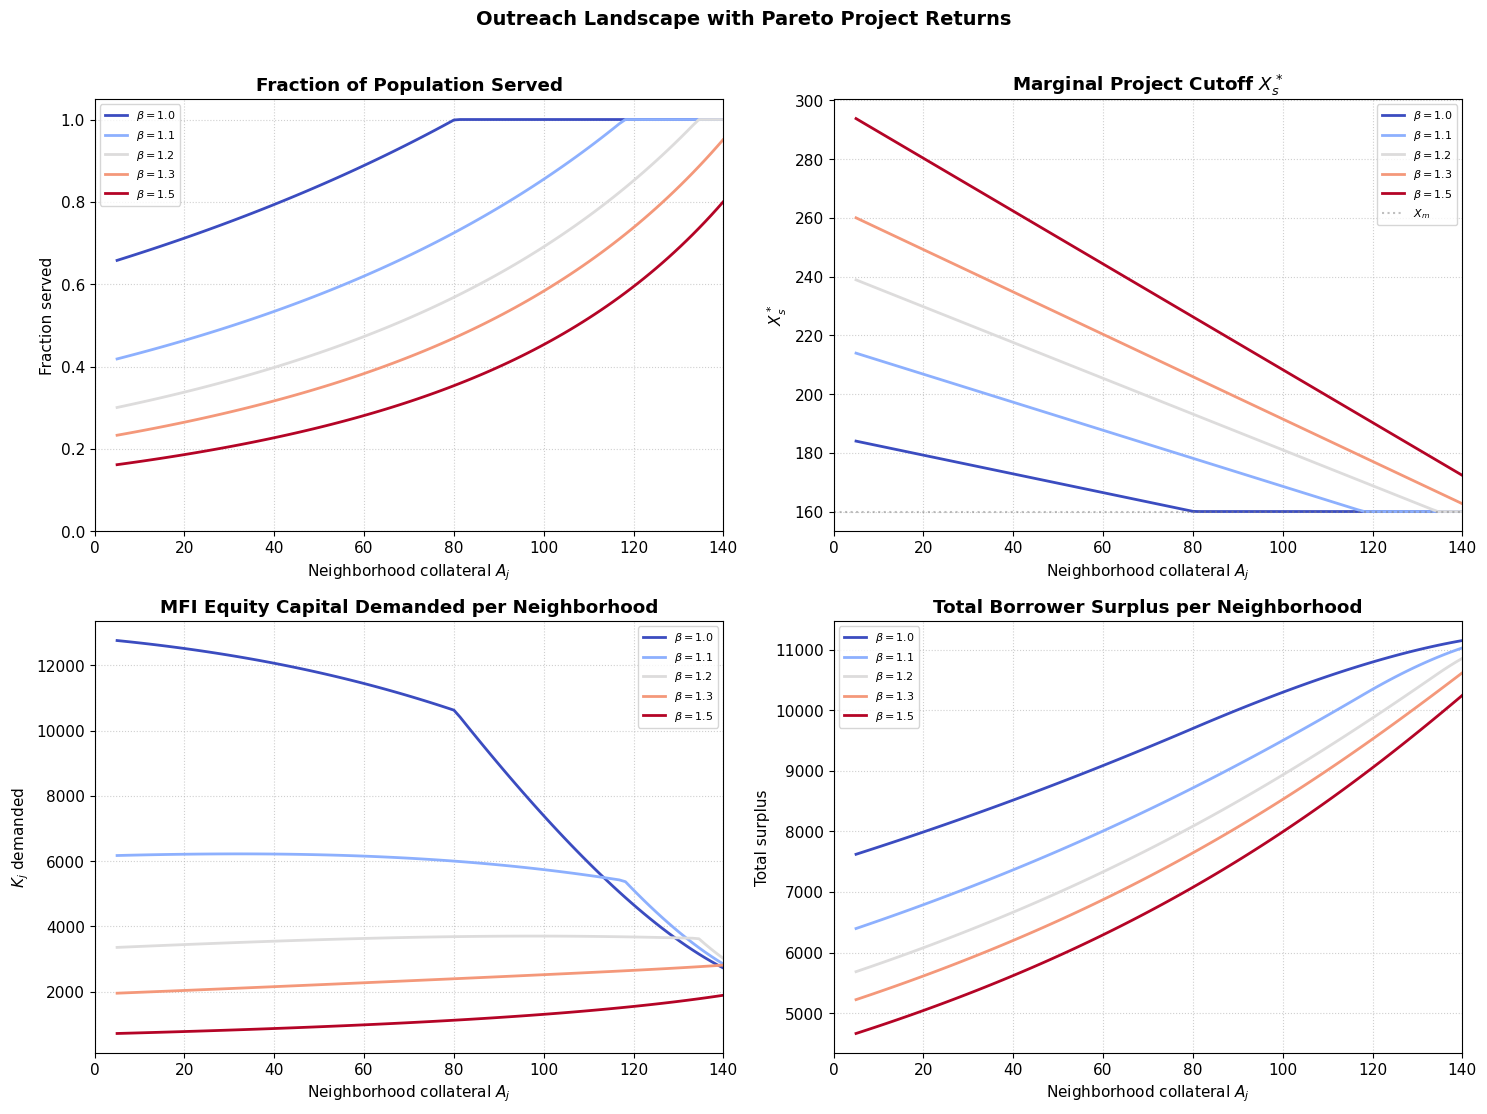

In [4]:
# Outreach landscape across neighborhoods for different beta

A_nbhds = np.linspace(5, 140, 100)
betas_compare = [1.0, 1.1, 1.2, 1.3, 1.5]
colors_beta = cm.coolwarm(np.linspace(0.0, 1.0, len(betas_compare)))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for beta_v, color in zip(betas_compare, colors_beta):
    frac_served_vals = []
    N_served_vals = []
    K_demand_vals = []
    total_surplus_vals = []
    X_star_vals = []
    
    for A_j in A_nbhds:
        bank = BankHetX(np.array([A_j]), beta=beta_v, dist_type='pareto', X_m=160, alpha_pareto=3.0)
        frac_served_vals.append(bank.frac_served(A_j))
        N_served_vals.append(bank.N_served(A_j))
        K_demand_vals.append(bank.K_demand_nbhd(A_j))
        total_surplus_vals.append(bank.total_surplus_nbhd(A_j))
        X_star_vals.append(bank.X_star(A_j))
    
    lbl = rf'$\beta = {beta_v:.1f}$'
    
    axes[0, 0].plot(A_nbhds, frac_served_vals, color=color, linewidth=2, label=lbl)
    axes[0, 1].plot(A_nbhds, X_star_vals, color=color, linewidth=2, label=lbl)
    axes[1, 0].plot(A_nbhds, K_demand_vals, color=color, linewidth=2, label=lbl)
    axes[1, 1].plot(A_nbhds, total_surplus_vals, color=color, linewidth=2, label=lbl)

axes[0, 0].set_title('Fraction of Population Served', weight='bold')
axes[0, 0].set_ylabel('Fraction served')
axes[0, 0].set_ylim(0, 1.05)

axes[0, 1].set_title(r'Marginal Project Cutoff $X_s^*$', weight='bold')
axes[0, 1].set_ylabel(r'$X_s^*$')
axes[0, 1].axhline(y=160, color='grey', linestyle=':', alpha=0.5, label=r'$X_m$')
# Guided line for X_hi removed for Pareto

axes[1, 0].set_title('MFI Equity Capital Demanded per Neighborhood', weight='bold')
axes[1, 0].set_ylabel(r'$K_j$ demanded')

axes[1, 1].set_title('Total Borrower Surplus per Neighborhood', weight='bold')
axes[1, 1].set_ylabel('Total surplus')

for ax in axes.flat:
    ax.set_xlabel(r'Neighborhood collateral $A_j$')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 140)

fig.suptitle('Outreach Landscape with Pareto Project Returns', 
             fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figs/fig-pareto-outreach-landscape.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. General Equilibrium: Clearing the Capital Market

Now we close the model. Total intermediary capital $K_{total}$ is fixed in the economy. Informed equity flows to the neighborhoods offering the highest return. In equilibrium, the rate of return $\beta^*$ equalizes across all served neighborhoods.

The **aggregate capital demand** is:

$$K_{demand}(\beta) = \sum_j K_j(A_j, \beta)$$

where $K_j$ is the equity absorbed by neighborhood $j$. This is a smooth, decreasing function of $\beta$ because:
- Higher $\beta$ raises the monitoring cost, reducing $X_s^*$ thresholds
- Fewer borrowers are served, and each absorbs different equity

We solve $K_{demand}(\beta^*) = K_{total}$ for the equilibrium.

In [5]:
def total_capital_demand(beta, A_nbhds, N_pop=100, X_m=160, alpha_pareto=3.0):
    """Aggregate capital demand across all neighborhoods for Pareto."""
    bank = BankHetX(A_nbhds, beta=beta, dist_type='pareto', X_m=X_m, alpha_pareto=alpha_pareto, N_pop=N_pop)
    return bank.capital_demand_grid(A_nbhds, N_potential=N_pop)


def total_borrowers_served(beta, A_nbhds, N_pop=100, X_m=160, alpha_pareto=3.0):
    """Total borrowers served across all neighborhoods for Pareto."""
    total = 0.0
    for A_j in A_nbhds:
        bank = BankHetX(np.array([A_j]), beta=beta, dist_type='pareto', X_m=X_m, alpha_pareto=alpha_pareto, N_pop=N_pop)
        total += bank.N_served(A_j)
    return total


def total_surplus(beta, A_nbhds, N_pop=100, X_m=160, alpha_pareto=3.0):
    """Total borrower surplus across all neighborhoods for Pareto."""
    total = 0.0
    for A_j in A_nbhds:
        bank = BankHetX(np.array([A_j]), beta=beta, dist_type='pareto', X_m=X_m, alpha_pareto=alpha_pareto, N_pop=N_pop)
        total += bank.total_surplus_nbhd(A_j)
    return total


# ---- Compute K_demand schedule ----
A_nbhds_eq = np.linspace(10, 140, 50)  # 50 neighborhoods
N_pop = 100  # borrowers per neighborhood

beta_range = np.linspace(1.0, 2.0, 80)
Kd_schedule = [total_capital_demand(b, A_nbhds_eq, N_pop) for b in beta_range]
N_schedule = [total_borrowers_served(b, A_nbhds_eq, N_pop) for b in beta_range]
S_schedule = [total_surplus(b, A_nbhds_eq, N_pop) for b in beta_range]

print(f"K_demand range: [{min(Kd_schedule):.0f}, {max(Kd_schedule):.0f}]")
print(f"N_served range: [{min(N_schedule):.0f}, {max(N_schedule):.0f}]")
print(f"Surplus range:  [{min(S_schedule):.0f}, {max(S_schedule):.0f}]")

K_demand range: [26382, 459881]
N_served range: [1319, 4517]
Surplus range:  [305953, 476131]


In [6]:
K_totals = [20000, 40000, 80000, 160000, 320000]
equilibria = {}

print("=== General Equilibrium under Pareto Returns ===")
for K_tot in K_totals:
    try:
        b_star = BankHetX.solve_equilibrium(A_nbhds_eq, K_tot, N_potential=N_pop, dist_type='pareto', X_m=160, alpha_pareto=3.0)
        n_tot = total_borrowers_served(b_star, A_nbhds_eq, N_pop)
        s_tot = total_surplus(b_star, A_nbhds_eq, N_pop)
        equilibria[K_tot] = {'beta': b_star, 'N': n_tot, 'surplus': s_tot}
        print(f"K_total = {K_tot:7,}: beta* = {b_star:.4f}, N_total = {n_tot:.0f}, Total Surplus = {s_tot:.0f}")
    except ValueError as e:
        print(f"K_total = {K_tot:7,}: collapsed ({e})")


=== General Equilibrium under Pareto Returns ===
K_total =  20,000: beta* = 2.7802, N_total = 1000, Total Surplus = 263717
K_total =  40,000: beta* = 1.6168, N_total = 1709, Total Surplus = 344336
K_total =  80,000: beta* = 1.4047, N_total = 2137, Total Surplus = 365818
K_total = 160,000: beta* = 1.2269, N_total = 2805, Total Surplus = 396230


K_total = 320,000: beta* = 1.0742, N_total = 3817, Total Surplus = 441866


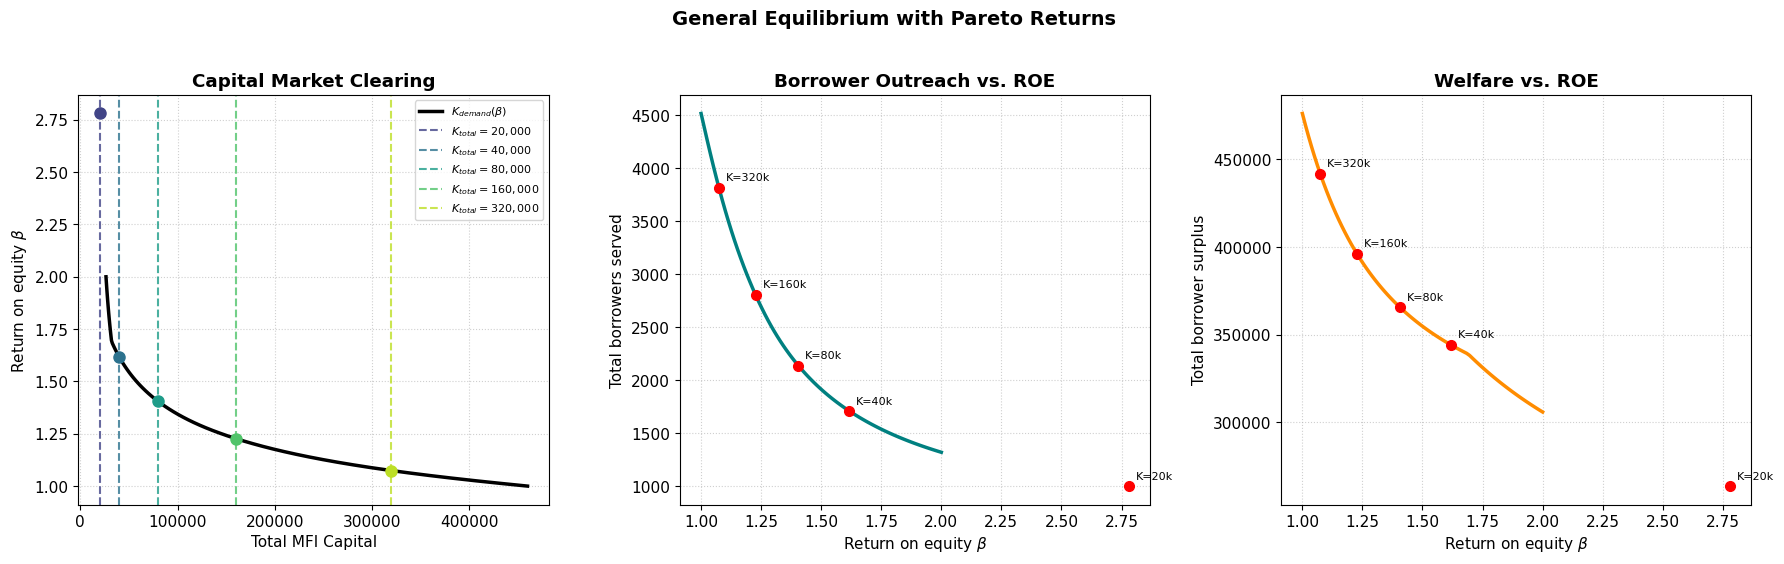

In [7]:
# ---- Visualization: Capital Market Clearing ----

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Plot 1: K_demand(beta) with K_total lines
ax = axes[0]
ax.plot(Kd_schedule, beta_range, 'k-', linewidth=2.5, label='$K_{demand}(\\beta)$')
for K_tot, color in zip(K_totals, cm.viridis(np.linspace(0.2, 0.9, len(K_totals)))):
    ax.axvline(x=K_tot, color=color, linestyle='--', alpha=0.8, label=f'$K_{{total}}={K_tot:,}$')
    if K_tot in equilibria:
        b = equilibria[K_tot]['beta']
        ax.plot(K_tot, b, 'o', color=color, markersize=8)
ax.set_xlabel('Total MFI Capital')
ax.set_ylabel(r'Return on equity $\beta$')
ax.set_title('Capital Market Clearing', weight='bold')
ax.legend(fontsize=8)

# Plot 2: N_served(beta)
ax = axes[1]
ax.plot(beta_range, N_schedule, 'teal', linewidth=2.5)
for K_tot in K_totals:
    if K_tot in equilibria:
        b = equilibria[K_tot]['beta']
        n = equilibria[K_tot]['N']
        ax.plot(b, n, 'ro', markersize=7)
        ax.annotate(f'K={K_tot//1000}k', (b, n), textcoords='offset points',
                   xytext=(5, 5), fontsize=8)
ax.set_xlabel(r'Return on equity $\beta$')
ax.set_ylabel('Total borrowers served')
ax.set_title('Borrower Outreach vs. ROE', weight='bold')

# Plot 3: Surplus(beta)
ax = axes[2]
ax.plot(beta_range, S_schedule, 'darkorange', linewidth=2.5)
for K_tot in K_totals:
    if K_tot in equilibria:
        b = equilibria[K_tot]['beta']
        s = equilibria[K_tot]['surplus']
        ax.plot(b, s, 'ro', markersize=7)
        ax.annotate(f'K={K_tot//1000}k', (b, s), textcoords='offset points',
                   xytext=(5, 5), fontsize=8)
        ax.set_xlabel(r'Return on equity $\beta$')
ax.set_ylabel('Total borrower surplus')
ax.set_title('Welfare vs. ROE', weight='bold')

plt.suptitle('General Equilibrium with Pareto Returns', 
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/fig-GE-clearing-hetX.png', dpi=300, bbox_inches='tight')


## 6. Depth vs. Breadth: The Two-Margin Decomposition

A key new result: when we inject additional capital $\Delta K$ into the economy, lending expands on **two margins** simultaneously:

1. **Extensive margin (breadth)**: New neighborhoods become served that were previously excluded
2. **Intensive margin (depth)**: Within already-served neighborhoods, more marginal borrowers (lower $X_s$) now qualify

Let's decompose the impact of a capital increase by comparing the equilibrium allocation across neighborhoods at different $K_{total}$ levels.

Comparing K_total = 20000 vs 320000


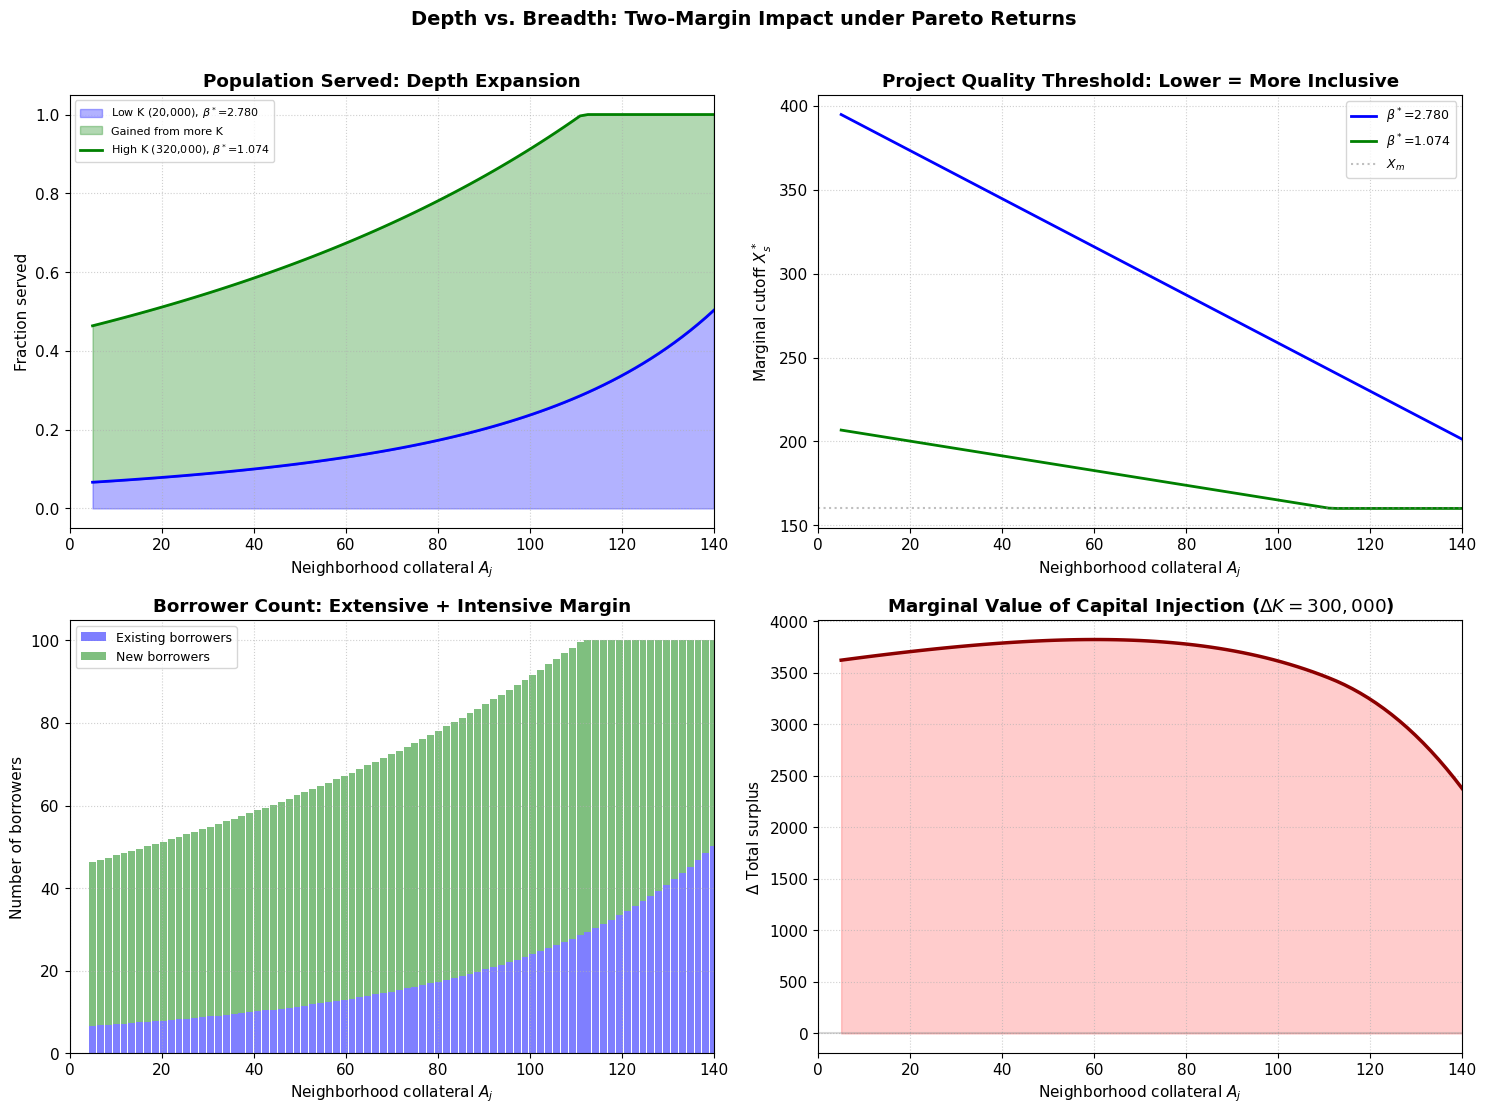

In [8]:
# Depth vs Breadth decomposition: compare two equilibria
# Pick two K_total values that have interior equilibria

K_low = None
K_high = None
for K in sorted(equilibria.keys()):
    if equilibria[K]['beta'] > 1.0:
        if K_low is None:
            K_low = K
        else:
            K_high = K

if K_low is None or K_high is None:
    # Fallback: just pick two
    K_candidates = sorted([k for k, v in equilibria.items() if v['beta'] > 1.0])
    if len(K_candidates) >= 2:
        K_low, K_high = K_candidates[0], K_candidates[-1]
    else:
        print("Need at least two interior equilibria. Adjusting K_totals...")
        K_low, K_high = 10000, 40000

print(f"Comparing K_total = {K_low} vs {K_high}")

beta_low = equilibria[K_low]['beta'] if K_low in equilibria else 1.5
beta_high = equilibria[K_high]['beta'] if K_high in equilibria else 1.1

# Compute neighborhood-level allocations for both equilibria
A_fine = np.linspace(5, 140, 80)

data_low = {'frac': [], 'N': [], 'K': [], 'surplus': [], 'Xstar': []}
data_high = {'frac': [], 'N': [], 'K': [], 'surplus': [], 'Xstar': []}

for A_j in A_fine:
    for beta_v, data in [(beta_low, data_low), (beta_high, data_high)]:
        bank = BankHetX(np.array([A_j]), beta=beta_v, dist_type='pareto', X_m=160, alpha_pareto=3.0, N_pop=N_pop)
        data['frac'].append(bank.frac_served(A_j))
        data['N'].append(bank.N_served(A_j))
        data['K'].append(bank.K_demand_nbhd(A_j))
        data['surplus'].append(bank.total_surplus_nbhd(A_j))
        data['Xstar'].append(bank.X_star(A_j))

# Convert to arrays
for d in [data_low, data_high]:
    for k in d:
        d[k] = np.array(d[k])

# Plot the decomposition
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ax = axes[0, 0]
ax.fill_between(A_fine, 0, data_low['frac'], alpha=0.3, color='blue', 
                label=f'Low K ({K_low:,}), $\\beta^*$={beta_low:.3f}')
ax.fill_between(A_fine, data_low['frac'], data_high['frac'], alpha=0.3, color='green',
                label=f'Gained from more K')
ax.plot(A_fine, data_high['frac'], 'g-', linewidth=2,
        label=f'High K ({K_high:,}), $\\beta^*$={beta_high:.3f}')
ax.plot(A_fine, data_low['frac'], 'b-', linewidth=2)
ax.set_ylabel('Fraction served')
ax.set_title('Population Served: Depth Expansion', weight='bold')
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(A_fine, data_low['Xstar'], 'b-', linewidth=2, label=f'$\\beta^*$={beta_low:.3f}')
ax.plot(A_fine, data_high['Xstar'], 'g-', linewidth=2, label=f'$\\beta^*$={beta_high:.3f}')
ax.axhline(y=160, color='grey', linestyle=':', alpha=0.5, label=r'$X_m$')
# Guided line for X_hi removed for Pareto
ax.set_ylabel('Marginal cutoff $X_s^*$')
ax.set_title('Project Quality Threshold: Lower = More Inclusive', weight='bold')
ax.legend(fontsize=9)

ax = axes[1, 0]
delta_N = data_high['N'] - data_low['N']
ax.bar(A_fine, data_low['N'], width=1.5, color='blue', alpha=0.5, label='Existing borrowers')
ax.bar(A_fine, delta_N, width=1.5, bottom=data_low['N'], color='green', alpha=0.5, label='New borrowers')
ax.set_ylabel('Number of borrowers')
ax.set_title('Borrower Count: Extensive + Intensive Margin', weight='bold')
ax.legend(fontsize=9)

ax = axes[1, 1]
delta_S = data_high['surplus'] - data_low['surplus']
ax.plot(A_fine, delta_S, 'darkred', linewidth=2.5)
ax.fill_between(A_fine, 0, delta_S, alpha=0.2, color='red')
ax.set_ylabel('$\\Delta$ Total surplus')
ax.set_title(f'Marginal Value of Capital Injection ($\\Delta K = {K_high - K_low:,}$)', weight='bold')
ax.axhline(y=0, color='grey', linestyle='-', alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Neighborhood collateral $A_j$')
    ax.set_xlim(0, 140)

fig.suptitle('Depth vs. Breadth: Two-Margin Impact under Pareto Returns', 
             fontsize=14, weight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figs/fig-depth-vs-breadth-pareto.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Mission Drift Under Commercial Pressure

One of the most important implications of this model is a precise formalization of **mission drift**. When the return on equity $\beta$ rises (e.g., because a social MFI is taken over by commercial investors, or because the overall capital supply shrinks):

1. **Cream-skimming within neighborhoods**: $X_s^*$ rises, so only the best projects within each neighborhood get funded
2. **Neighborhood abandonment**: Poorer neighborhoods with low $A_j$ become entirely unserved
3. **Capital reallocation**: Equity migrates from poor to rich neighborhoods

Let's visualize this "mission drift" as $\beta$ increases from the social benchmark to a fully commercial level.

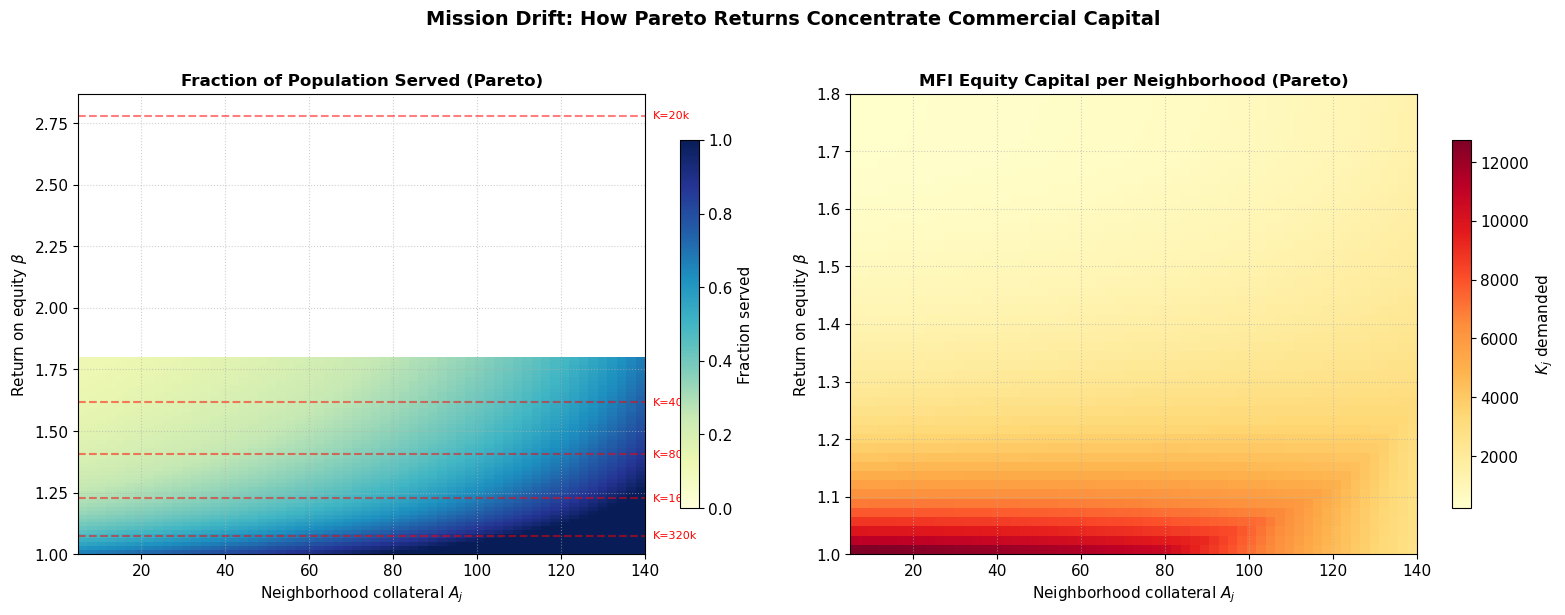

In [9]:
# Mission drift visualization: heatmap of service coverage under Pareto
beta_mission = np.linspace(1.0, 1.8, 50)
A_mission = np.linspace(5, 140, 60)

frac_matrix = np.zeros((len(beta_mission), len(A_mission)))
K_matrix = np.zeros_like(frac_matrix)

for i, b in enumerate(beta_mission):
    for j, A_j in enumerate(A_mission):
        bank = BankHetX(np.array([A_j]), beta=b, dist_type='pareto', X_m=160, alpha_pareto=3.0, N_pop=N_pop)
        frac_matrix[i, j] = bank.frac_served(A_j)
        K_matrix[i, j] = bank.K_demand_nbhd(A_j)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Fraction served
im1 = axes[0].imshow(frac_matrix, aspect='auto', origin='lower',
                     extent=[A_mission[0], A_mission[-1], beta_mission[0], beta_mission[-1]],
                     cmap='YlGnBu', vmin=0, vmax=1)
axes[0].set_xlabel('Neighborhood collateral $A_j$', fontsize=11)
axes[0].set_ylabel(r'Return on equity $\beta$', fontsize=11)
axes[0].set_title('Fraction of Population Served (Pareto)', weight='bold', fontsize=12)
fig.colorbar(im1, ax=axes[0], label='Fraction served', shrink=0.8)

# Mark equilibria
for K_tot, eq in sorted(equilibria.items()):
    if eq['beta'] > 1.0:
        axes[0].axhline(y=eq['beta'], color='red', linestyle='--', alpha=0.5)
        axes[0].text(A_mission[-1]+2, eq['beta'], f"K={K_tot//1000}k", fontsize=8, 
                    va='center', color='red')

# Heatmap 2: Capital allocated
im2 = axes[1].imshow(K_matrix, aspect='auto', origin='lower',
                     extent=[A_mission[0], A_mission[-1], beta_mission[0], beta_mission[-1]],
                     cmap='YlOrRd')
axes[1].set_xlabel('Neighborhood collateral $A_j$', fontsize=11)
axes[1].set_ylabel(r'Return on equity $\beta$', fontsize=11)
axes[1].set_title('MFI Equity Capital per Neighborhood (Pareto)', weight='bold', fontsize=12)
fig.colorbar(im2, ax=axes[1], label='$K_j$ demanded', shrink=0.8)

fig.suptitle('Mission Drift: How Pareto Returns Concentrate Commercial Capital', 
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/fig-mission-drift-heatmap-pareto.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Social Investor Impact: Targeted vs. Untargeted Capital Injection

Suppose a social investor has $\Delta K$ of capital to inject into the economy. Two strategies:

**Strategy A (Untargeted)**: Add $\Delta K$ to the general pool. This lowers $\beta^*$ economy-wide, benefiting all neighborhoods.

**Strategy B (Targeted to poor neighborhoods)**: Inject $\Delta K$ as concessional equity ($\beta_{subsidy} < \beta^*$) in specific poor neighborhoods. This directly expands access there without changing $\beta^*$ elsewhere.

Let's compare the total impact (borrowers reached, surplus generated) of each strategy.

Baseline: K_total = 20,000, beta* = 2.7802
          N_total = 1000, Surplus = 263717



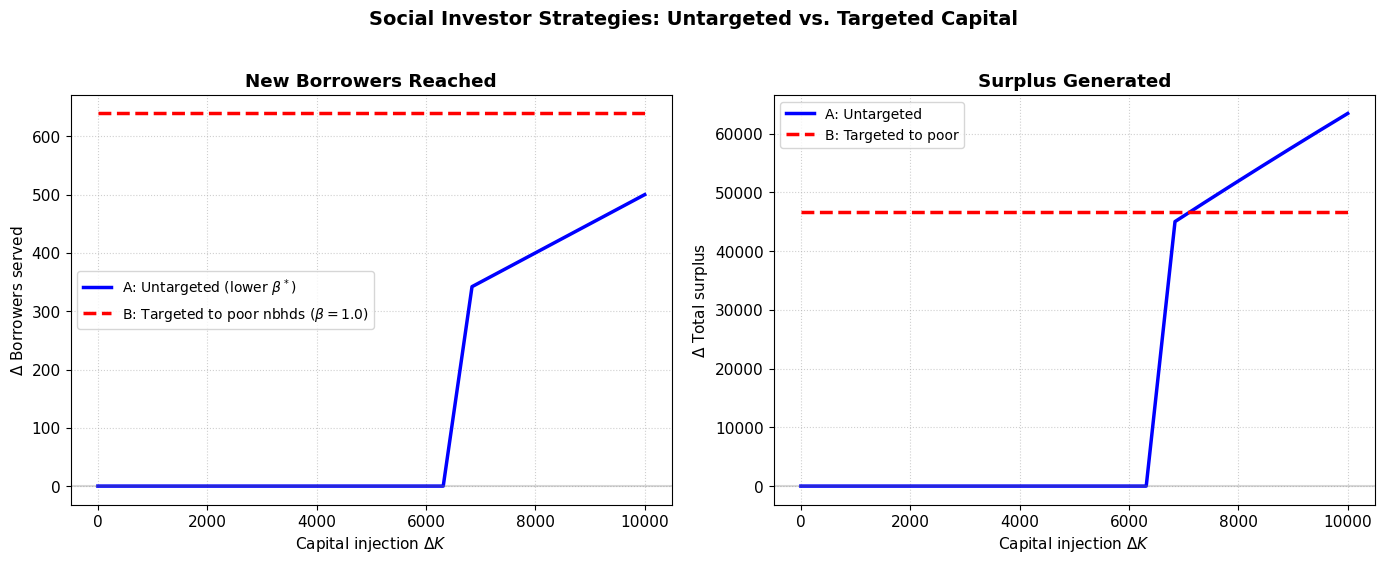

In [10]:
# Social investor impact analysis
# Pick a baseline K_total and compute a reference equilibrium

# Use the middle K_total as baseline
K_baseline = sorted([k for k, v in equilibria.items() if v['beta'] > 1.01])[0]
beta_baseline = equilibria[K_baseline]['beta']
N_baseline = equilibria[K_baseline]['N']
S_baseline = equilibria[K_baseline]['surplus']

print(f"Baseline: K_total = {K_baseline:,}, beta* = {beta_baseline:.4f}")
print(f"          N_total = {N_baseline:.0f}, Surplus = {S_baseline:.0f}")
print()

# Inject amounts
delta_Ks = np.linspace(0, K_baseline * 0.5, 20)

# Strategy A: Untargeted (increase K_total)
results_A = {'N': [], 'S': [], 'beta': []}
for dK in delta_Ks:
    K_new = K_baseline + dK
    try:
        kd_at_1 = total_capital_demand(1.0, A_nbhds_eq, N_pop)
        if K_new >= kd_at_1:
            b = 1.0
        else:
            b = brentq(lambda beta: total_capital_demand(beta, A_nbhds_eq, N_pop) - K_new,
                       1.0, 2.0)
    except:
        b = beta_baseline
    results_A['beta'].append(b)
    results_A['N'].append(total_borrowers_served(b, A_nbhds_eq, N_pop))
    results_A['S'].append(total_surplus(b, A_nbhds_eq, N_pop))

# Strategy B: Targeted to poorest 10 neighborhoods at beta=1.0 (social equity)
# The rest of the economy still clears at beta*
# Approximate: in poor neighborhoods, use beta=1.0; elsewhere, beta = beta_baseline
results_B = {'N': [], 'S': []}
A_poor = A_nbhds_eq[:10]  # poorest 10 neighborhoods
A_rest = A_nbhds_eq[10:]  # remaining neighborhoods

for dK in delta_Ks:
    # Poor neighborhoods get subsidized equity at beta=1.0
    N_poor = 0
    S_poor = 0
    for A_j in A_poor:
        bank = BankHetX(np.array([A_j]), beta=1.0, dist_type='pareto', X_m=160, alpha_pareto=3.0, N_pop=N_pop)
        N_poor += bank.N_served(A_j)
        S_poor += bank.total_surplus_nbhd(A_j)
    
    # Rest of economy at beta_baseline (unchanged)
    N_rest = 0
    S_rest = 0
    for A_j in A_rest:
        bank = BankHetX(np.array([A_j]), beta=beta_baseline, dist_type='pareto', X_m=160, alpha_pareto=3.0, N_pop=N_pop)
        N_rest += bank.N_served(A_j)
        S_rest += bank.total_surplus_nbhd(A_j)
    
    results_B['N'].append(N_poor + N_rest)
    results_B['S'].append(S_poor + S_rest)

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(delta_Ks, np.array(results_A['N']) - N_baseline, 'b-', linewidth=2.5, 
        label='A: Untargeted (lower $\\beta^*$)')
ax.plot(delta_Ks, np.array(results_B['N']) - N_baseline, 'r--', linewidth=2.5,
        label='B: Targeted to poor nbhds ($\\beta=1.0$)')
ax.set_xlabel('Capital injection $\\Delta K$')
ax.set_ylabel('$\\Delta$ Borrowers served')
ax.set_title('New Borrowers Reached', weight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0, color='grey', linestyle='-', alpha=0.3)

ax = axes[1]
ax.plot(delta_Ks, np.array(results_A['S']) - S_baseline, 'b-', linewidth=2.5,
        label='A: Untargeted')
ax.plot(delta_Ks, np.array(results_B['S']) - S_baseline, 'r--', linewidth=2.5,
        label='B: Targeted to poor')
ax.set_xlabel('Capital injection $\\Delta K$')
ax.set_ylabel('$\\Delta$ Total surplus')
ax.set_title('Surplus Generated', weight='bold')
ax.legend(fontsize=10)
ax.axhline(y=0, color='grey', linestyle='-', alpha=0.3)

fig.suptitle('Social Investor Strategies: Untargeted vs. Targeted Capital', 
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/fig-social-investor-strategies-pareto.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Analytical Results: Closed-Form Expressions

### Proposition: Marginal Project Cutoff

For a neighborhood with collateral $A_j$ and a uniform distribution $X_s \sim U[\underline{X}, \bar{X}]$, the marginal project cutoff under leveraged lending with equity return $\beta$ is:

$$X_s^*(A_j, \beta) = \frac{\gamma I + f + c(\beta) \cdot \kappa(\beta) \cdot \left[\frac{pB_0}{\Delta} + \gamma I + f - A_j\right]}{p\left[1 + c(\beta) \cdot \kappa(\beta)\right]}$$

where:
- $c(\beta) = \frac{\beta \Delta}{(\alpha - 1)\beta p + \gamma q}$ is the monitoring sensitivity
- $\kappa(\beta) = 1 + \frac{(\beta - \gamma)}{\beta} \frac{q}{\Delta}$ is the effective monitoring cost multiplier

### Comparative Statics

**Proposition**: $\frac{\partial X_s^*}{\partial \beta} > 0$ and $\frac{\partial X_s^*}{\partial A_j} < 0$.

- Higher $\beta$ raises the cutoff: cream-skimming intensifies under commercial pressure
- Higher $A_j$ lowers the cutoff: richer neighborhoods can fund more marginal projects

### Fraction Served

Under the uniform distribution:
$$\text{frac\_served}(A_j, \beta) = \frac{\bar{X} - X_s^*(A_j, \beta)}{\bar{X} - \underline{X}}$$

### Total Capital Demand (Analytical)

For the leveraged regime, $I^m(A_j, X_s) = \frac{q}{\beta \Delta} \cdot m^*(A_j, X_s)$. Since $m^*$ is linear in $X_s$, the integral over the uniform distribution has a closed form:

$$K_j(\beta) = \frac{N_{pop}}{\bar{X} - \underline{X}} \cdot \frac{q}{\beta \Delta} \cdot \frac{c(\beta)}{2} \cdot \left[\frac{pB_0}{\Delta} + \gamma I + f - A_j - p \cdot X_s^*\right] \cdot \left[X_{nm} - X_s^*\right]$$

where $X_{nm}(A_j) = \frac{pB_0/\Delta + \gamma I + f - A_j}{p}$ is the threshold above which no monitoring is needed.

Let's verify these analytical expressions against our numerical integration.

In [11]:
# Compare analytical vs numerical for several (A_j, beta) pairs using Pareto returns
print("=== Verification: Analytical vs Numerical K_demand (Pareto) ===")
print(f"{'A_j':>6} {'beta':>6} {'K_numerical':>12} {'K_analytical':>14} {'Match':>8}")
print("-" * 50)

for A_j in [30, 60, 90, 120]:
    for beta_v in [1.0, 1.2, 1.5]:
        bank = BankHetX(np.array([A_j]), beta=beta_v, dist_type='pareto', X_m=160, alpha_pareto=3.0, N_pop=N_pop)
        K_num = bank.K_demand_nbhd(A_j, method='numerical')
        K_ana = bank.K_demand_nbhd(A_j, method='analytical')
        match = abs(K_num - K_ana) < 0.1 * max(K_num, 1.0)
        print(f"{A_j:>6} {beta_v:>6.1f} {K_num:>12.2f} {K_ana:>14.2f} {'OK' if match else 'DIFF':>8}")

=== Verification: Analytical vs Numerical K_demand (Pareto) ===
   A_j   beta  K_numerical   K_analytical    Match
--------------------------------------------------
    30    1.0     12309.12       12309.12       OK
    30    1.2      3493.48        3493.48       OK
    30    1.5       817.75         817.75       OK
    60    1.0     11442.15       11442.15       OK
    60    1.2      3627.42        3627.42       OK
    60    1.5       979.33         979.33       OK
    90    1.0      8964.36        8964.36       OK
    90    1.2      3696.29        3696.29       OK
    90    1.5      1204.67        1204.67       OK
   120    1.0      4659.25        4659.25       OK
   120    1.2      3672.51        3672.51       OK
   120    1.5      1543.52        1543.52       OK


## 10. Effect of Pareto Shape Parameter ($\alpha_{\text{pareto}}$)

Let's analyze how the Pareto shape parameter $\alpha_{\text{pareto}}$ (which controls the skewness and tail weight of project quality) affects the general equilibrium. A higher $\alpha_{\text{pareto}}$ means the tail of high-quality projects is even thinner, and borrowers are more heavily clustered near the lower bound $X_m = 160$.

In [12]:
# ---- Experiment: Varying Pareto Shape Parameter (alpha) ----
alphas = [2.0, 2.5, 3.0, 3.5, 4.0]
K_eq = 80000.0

print(f"{'Alpha':>8} {'beta*':>8} {'N_total':>10} {'Surplus':>10}")
print("-" * 42)

results_alpha = []
for a in alphas:
    try:
        b_star = BankHetX.solve_equilibrium(A_nbhds_eq, K_eq, N_potential=N_pop, dist_type='pareto', X_m=160, alpha_pareto=a)
        n_tot = total_borrowers_served(b_star, A_nbhds_eq, N_pop, X_m=160, alpha_pareto=a)
        s_tot = total_surplus(b_star, A_nbhds_eq, N_pop, X_m=160, alpha_pareto=a)
        results_alpha.append({'alpha': a, 'beta': b_star, 'N': n_tot, 'surplus': s_tot})
        print(f"{a:>8.1f} {b_star:>8.4f} {n_tot:>10.0f} {s_tot:>10.0f}")
    except ValueError:
        print(f"{a:>8.1f} collapsed")


   Alpha    beta*    N_total    Surplus
------------------------------------------
     2.0   1.4536       2668     781865
     2.5   1.4270       2375     506809
     3.0   1.4047       2137     365818


     3.5   1.3852       1944     280044


     4.0   1.3676       1786     222698


## 11. Summary and Conclusions

### What We've Shown

1. **Within-neighborhood heterogeneity in project returns creates a smooth intensive margin**: The MFI optimally serves borrowers with $X_s \geq X_s^*(A_j, \beta)$, and the cutoff rises with $\beta$ (the return on equity) and falls with $A_j$ (neighborhood wealth).

2. **Both N and K are endogenous**: The number of borrowers is determined by the cutoff $X_s^*$, and capital flows across neighborhoods seeking the highest return. The equilibrium $\beta^*$ clears both markets simultaneously.

3. **Mission drift is formalized**: An increase in $\beta$ causes *both* cream-skimming within neighborhoods (intensive margin) and abandonment of poor neighborhoods (extensive margin). This is the first formal model to capture both channels.

4. **Donor targeting has richer tradeoffs**: Untargeted capital injections lower $\beta^*$ everywhere, benefiting all neighborhoods. Targeted injections at concessional rates can directly serve excluded populations without affecting the commercial equilibrium.

5. **Analytical tractability**: The uniform distribution yields closed-form expressions for all key objects ($X_s^*$, $K_j$, $N_j$), enabling clean comparative statics propositions.

### Directions for Extension

- **Re-introduce $F > 0$**: Fixed entry costs create a discrete entry/exit decision per neighborhood, amplifying the extensive margin
- **Non-uniform distributions**: Pareto or log-normal project returns would better capture empirical patterns
- **Endogenous $\gamma$**: Allow the cost of uninformed capital to respond to the overall lending portfolio risk
- **Borrower heterogeneity in $A$**: Combine within-neighborhood $A$ and $X_s$ distributions for the most general model